In [56]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import glob


from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from scipy.optimize import curve_fit
from scipy.special import factorial


from pathlib import Path
import matplotlib.pyplot as plt





MAX_Q15 = 32767 / 32768


In [68]:



def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu



def process_all_runs(data_dir="data", rng=None):
    

    if not os.path.exists(data_dir):
        print(f"Error: Directory '{data_dir}' does not exist.")
        return {}

    # Get all subdirectories in Data
    folders = [
        f
        for f in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, f))
    ]

    if not folders:
        print(f"No run folders found inside '{data_dir}'.")
        return {}

    results = {}

    for folder_name in sorted(folders):
        
        runfile_path = os.path.join(data_dir, folder_name)
        vel_raw = float(folder_name.split("_")[0])
        vel = vel_raw / 1000.0 
        # folder_name = f'{vel}'
        bin_pattern = os.path.join(runfile_path, "events_*.bin")
        tiepoints_path = os.path.join(runfile_path, "tiepoints.csv")

        # Check if the required files exist before trying to process
        if not glob.glob(bin_pattern) or not os.path.exists(tiepoints_path):
            print(
                f"[{folder_name}] Missing events_*.bin or tiepoints.csv. Skipping..."
            )
            continue

        # 1. Load and unpack data
        raw = load_run(bin_pattern)

        ts_us, energy, chb = unpack(raw)
        # chb = np.round(chb).astype(int)

        # Filter positive timestamps and keep energy aligned
        valid_mask = ts_us > 0
        ts_us = ts_us[valid_mask]
        energy = energy[valid_mask]
        chb = chb[valid_mask]

        if len(ts_us) > 1:
            # print(ts_us[-1])
            # print(ts_us[0])
            print(
                f"[{folder_name}] {len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s"
            )
        else:
            print(f"[{folder_name}] No events found. Skipping...")
            continue

        # Clock drift correction
        a, b, ppm = fit_clock(tiepoints_path)
        print(f"[{folder_name}] Crystal drift: {ppm:+.1f} ppm")
        t_unix = counter_to_unix(ts_us, a, b)

        # 3. Chunk splitting
        split_indices = np.where(np.diff(chb) != 0)[0] + 1

        energy_chunks = np.split(energy, split_indices)
        ts_chunks = np.split(ts_us, split_indices)
        chb_chunks = np.split(chb, split_indices)

        chunk_directions = [c[0] for c in chb_chunks]

        # 4. Group into forward and backward lists
        forward_energies = [
            e for e, d in zip(energy_chunks, chunk_directions) if d == 1
        ]
        backward_energies = [
            e for e, d in zip(energy_chunks, chunk_directions) if d == 0
        ]

        forward_times = [
            t for t, d in zip(ts_chunks, chunk_directions) if d == 1
        ]
        backward_times = [
            t for t, d in zip(ts_chunks, chunk_directions) if d == 0
        ]

        results[folder_name] = {
            "runfile": folder_name,
            "runfile_path": runfile_path,
            "ts_us": ts_us,
            "energy": energy,
            "t_unix": t_unix,
            "chb": chb,
            "energy_chunks": energy_chunks,
            "ts_chunks": ts_chunks,
            "chunk_directions": np.array(chunk_directions),
            "forward_energies": forward_energies,
            "backward_energies": backward_energies,
            "forward_times": forward_times,
            "backward_times": backward_times,
            "velocities": vel,
        }

    return results



processed_runs = process_all_runs(data_dir='data')


[0_runfile] 254543 events, span 300.3 s
[0_runfile] Crystal drift: -27.9 ppm
[100_runfile] 263530 events, span 0.0 s
[100_runfile] Crystal drift: +33.7 ppm
[10_runfile] 255762 events, span 18446744073709.4 s
[10_runfile] Crystal drift: -49.6 ppm
[110_runfile] 264880 events, span 18446744073709.0 s
[110_runfile] Crystal drift: -36.4 ppm


/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_84733/921843952.py:74: RuntimeWarning: overflow encountered in scalar subtract
  f"[{folder_name}] {len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s"


[120_runfile] 265104 events, span 0.0 s
[120_runfile] Crystal drift: -36.5 ppm
[130_runfile] 267583 events, span 0.5 s
[130_runfile] Crystal drift: -35.4 ppm
[140_runfile] 267954 events, span 18446744073708.7 s
[140_runfile] Crystal drift: -32.4 ppm
[150_runfile] 269055 events, span 0.3 s
[150_runfile] Crystal drift: -37.6 ppm
[160_runfile] 269564 events, span 0.5 s
[160_runfile] Crystal drift: -27.2 ppm
[170_runfile] 270920 events, span 0.0 s
[170_runfile] Crystal drift: -43.4 ppm
[180_runfile] 271337 events, span 18446744073708.8 s
[180_runfile] Crystal drift: -29.9 ppm
[190_runfile] 272601 events, span 18446744073709.4 s
[190_runfile] Crystal drift: -47.5 ppm
[200_runfile] 272481 events, span 0.0 s
[200_runfile] Crystal drift: -46.2 ppm
[20_runfile] 255335 events, span 0.2 s
[20_runfile] Crystal drift: -35.5 ppm
[210_runfile] 274419 events, span 0.1 s
[210_runfile] Crystal drift: -13.7 ppm
[220_runfile] 274975 events, span 0.1 s
[220_runfile] Crystal drift: -48.2 ppm
[230_runfile] 2

300318473
389
[0.0] 254543 events, span 300.3 s
[0.0] Crystal drift: -27.9 ppm
300838717
300830373
[0.1] 263530 events, span 0.0 s
[0.1] Crystal drift: +33.7 ppm
300146367
300318786
[0.01] 255762 events, span 18446744073709.4 s
[0.01] Crystal drift: -49.6 ppm
300315978
300839019
[0.11] 264880 events, span 18446744073709.0 s
[0.11] Crystal drift: -36.4 ppm


/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_84733/3040765285.py:74: RuntimeWarning: overflow encountered in scalar subtract
  f"[{folder_name}] {len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s"


300328708
300318725
[0.12] 265104 events, span 0.0 s
[0.12] Crystal drift: -36.5 ppm
300800243
300329226
[0.13] 267583 events, span 0.5 s
[0.13] Crystal drift: -35.4 ppm
299978492
300801611
[0.14] 267954 events, span 18446744073708.7 s
[0.14] Crystal drift: -32.4 ppm
300308018
299980511
[0.15] 269055 events, span 0.3 s
[0.15] Crystal drift: -37.6 ppm
300807832
300312866
[0.16] 269564 events, span 0.5 s
[0.16] Crystal drift: -27.2 ppm
300836468
300810773
[0.17] 270920 events, span 0.0 s
[0.17] Crystal drift: -43.4 ppm
300129688
300839976
[0.18] 271337 events, span 18446744073708.8 s
[0.18] Crystal drift: -29.9 ppm
299986643
300136286
[0.19] 272601 events, span 18446744073709.4 s
[0.19] Crystal drift: -47.5 ppm
300019593
299988869
[0.2] 272481 events, span 0.0 s
[0.2] Crystal drift: -46.2 ppm
300358217
300150076
[0.02] 255335 events, span 0.2 s
[0.02] Crystal drift: -35.5 ppm
300076154
300019665
[0.21] 274419 events, span 0.1 s
[0.21] Crystal drift: -13.7 ppm
300136758
300077526
[0.22] 2

/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_84733/1728826157.py:38: RuntimeWarning: overflow encountered in scalar subtract
  bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_84733/1728826157.py:26: RuntimeWarning: overflow encountered in scalar subtract
  fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6


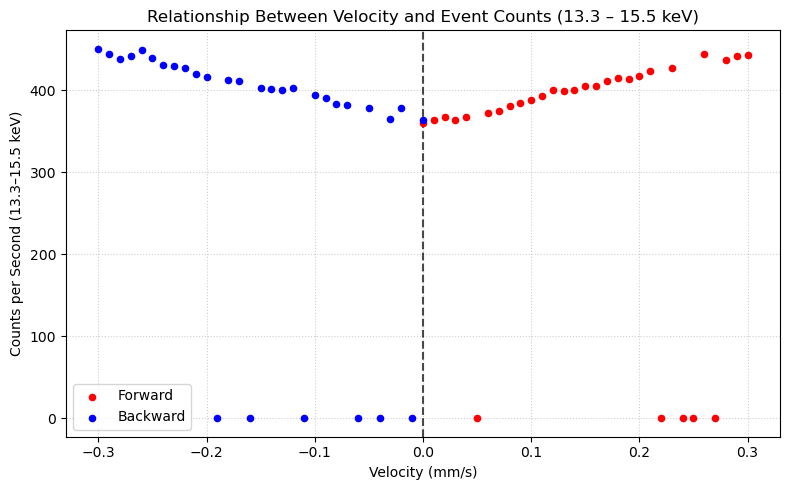

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Energy window (keV)
e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts = [], []
bwd_vels, bwd_counts = [], []

for runfile, data in processed_runs.items():
    # try:
    #     vel_raw = float(runfile.split("_")[0])
    #     vel = vel_raw / 1000.0  # Convert integer back to mm/s
    # except ValueError:
    #     print(f"Skipping {runfile}: Cannot parse numerical velocity from name.")
    #     continue
    # print(runfile)
    runfile = float(runfile)
    fwd_chunks = data["forward_energies"]
    bwd_chunks = data["backward_energies"]
    fwd_times = data["forward_times"]
    bwd_times = data["backward_times"]

    # --- Forward Direction ---
    fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6
    if fwd_dur_s > 0 and len(fwd_chunks) > 0:
        fwd_energy_all = np.concatenate(fwd_chunks)
        fwd_kev = adu_to_kev(fwd_energy_all)
        fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
        fwd_rate = fwd_count / fwd_dur_s

        if fwd_rate > 0:
            fwd_vels.append(runfile)
            fwd_counts.append(fwd_rate)

    # --- Backward Direction ---
    bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
    if bwd_dur_s > 0 and len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
        bwd_rate = bwd_count / bwd_dur_s

        if bwd_rate > 0:
            bwd_vels.append(-runfile)
            bwd_counts.append(bwd_rate)


plt.figure(figsize=(8, 5))

plt.scatter(
    fwd_vels,
    fwd_counts,
    color="red",
    label="Forward",
    marker="o",
    s=20,
    zorder=3,
)
plt.scatter(
    bwd_vels,
    bwd_counts,
    color="blue",
    label="Backward",
    marker="o",
    s=20,
    zorder=3,
)

plt.title(
    f"Relationship Between Velocity and Event Counts ({e_start} – {e_end} keV)"
)
plt.xlabel("Velocity (mm/s)")
plt.ylabel(f"Counts per Second ({e_start}–{e_end} keV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_84733/1577125285.py:33: RuntimeWarning: overflow encountered in scalar subtract
  bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_84733/1577125285.py:20: RuntimeWarning: overflow encountered in scalar subtract
  fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6


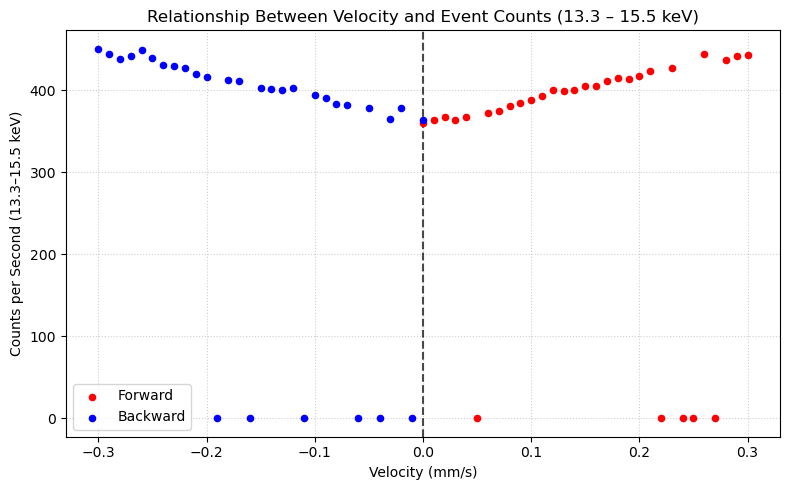

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Energy window (keV)
e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts = [], []
bwd_vels, bwd_counts = [], []

for runfile, data in processed_runs.items():

    runfile = float(runfile)
    fwd_chunks = data["forward_energies"]
    bwd_chunks = data["backward_energies"]
    fwd_times = data["forward_times"]
    bwd_times = data["backward_times"]

    # --- Forward Direction ---
    fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6

    if fwd_dur_s > 0 and len(fwd_chunks) > 0:
        fwd_energy_all = np.concatenate(fwd_chunks)
        fwd_kev = adu_to_kev(fwd_energy_all)
        fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
        fwd_rate = fwd_count / fwd_dur_s

        if fwd_rate > 0:
            fwd_vels.append(runfile)
            fwd_counts.append(fwd_rate)

    # --- Backward Direction ---
    bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
    if bwd_dur_s > 0 and len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
        bwd_rate = bwd_count / bwd_dur_s

        if bwd_rate > 0:
            bwd_vels.append(-runfile)
            bwd_counts.append(bwd_rate)


plt.figure(figsize=(8, 5))

plt.scatter(
    fwd_vels,
    fwd_counts,
    color="red",
    label="Forward",
    marker="o",
    s=20,
    zorder=3,
)
plt.scatter(
    bwd_vels,
    bwd_counts,
    color="blue",
    label="Backward",
    marker="o",
    s=20,
    zorder=3,
)

plt.title(
    f"Relationship Between Velocity and Event Counts ({e_start} – {e_end} keV)"
)
plt.xlabel("Velocity (mm/s)")
plt.ylabel(f"Counts per Second ({e_start}–{e_end} keV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
h_all = {}
adu_all = {}

for label, run in processed_runs.items():
    energy = run["energy"]

    # Define integer ADU bins spanning the min-to-max range
    min_adu = int(np.floor(np.min(energy)))
    max_adu = int(np.ceil(np.max(energy)))
    bins = np.arange(min_adu, max_adu + 2)

    # Compute histogram
    h, b = np.histogram(energy, bins=bins)
    bin_centers = 0.5 * (b[:-1] + b[1:])  # Proper bin centers instead of right edges

    h_all[label] = (h)
    adu_all[label] = (bin_centers)


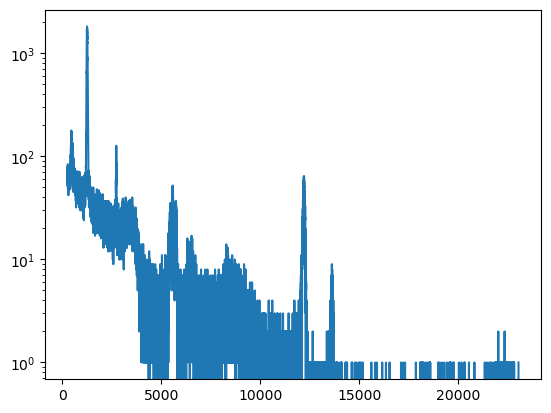

In [62]:
plt.plot(adu_all['0.02'],h_all['0.02'], label ='0.02')
# plt.plot(adu_all[1],h_all[1], alpha =0.3, color = 'red', label = 'With Absorber')

plt.yscale('log')
# plt.xscale('log')
# plt.xlim(kev_to_adu(13),kev_to_adu(16))

##RATE WITH AND WITHOUT ABSORBR